# Travel Planning Workflow - Evaluation

Evaluate agent responses from a multi-agent travel planning workflow using Azure AI evaluators.

## Prerequisites

Install required packages:
```bash
pip install matplotlib networkx python-dotenv
pip install azure-ai-projects --extra-index-url https://pkgs.dev.azure.com/azure-sdk/public/_packaging/azure-sdk-for-python/pypi/simple --pre --force-reinstall
```

Set environment variables in `.env`:
```
AZURE_AI_PROJECT_ENDPOINT=your_endpoint
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4o-mini
```

In [ ]:
import json
import os
import time
from pprint import pprint
from dotenv import load_dotenv
from azure.ai.projects import AIProjectClient
from azure.identity import DefaultAzureCredential
import matplotlib.pyplot as plt
import networkx as nx

load_dotenv()

project_client = AIProjectClient(
    endpoint=os.environ["AZURE_AI_PROJECT_ENDPOINT"],
    credential=DefaultAzureCredential(),
    api_version="2025-11-15-preview"
)
openai_client = project_client.get_openai_client()
print("✓ Connected to Azure AI Project")

✓ Connected to Azure AI Project


## Step 1: Run Workflow

Execute the multi-agent travel planning workflow. This generates response IDs that will be used for evaluation.

The workflow structure is as follows:
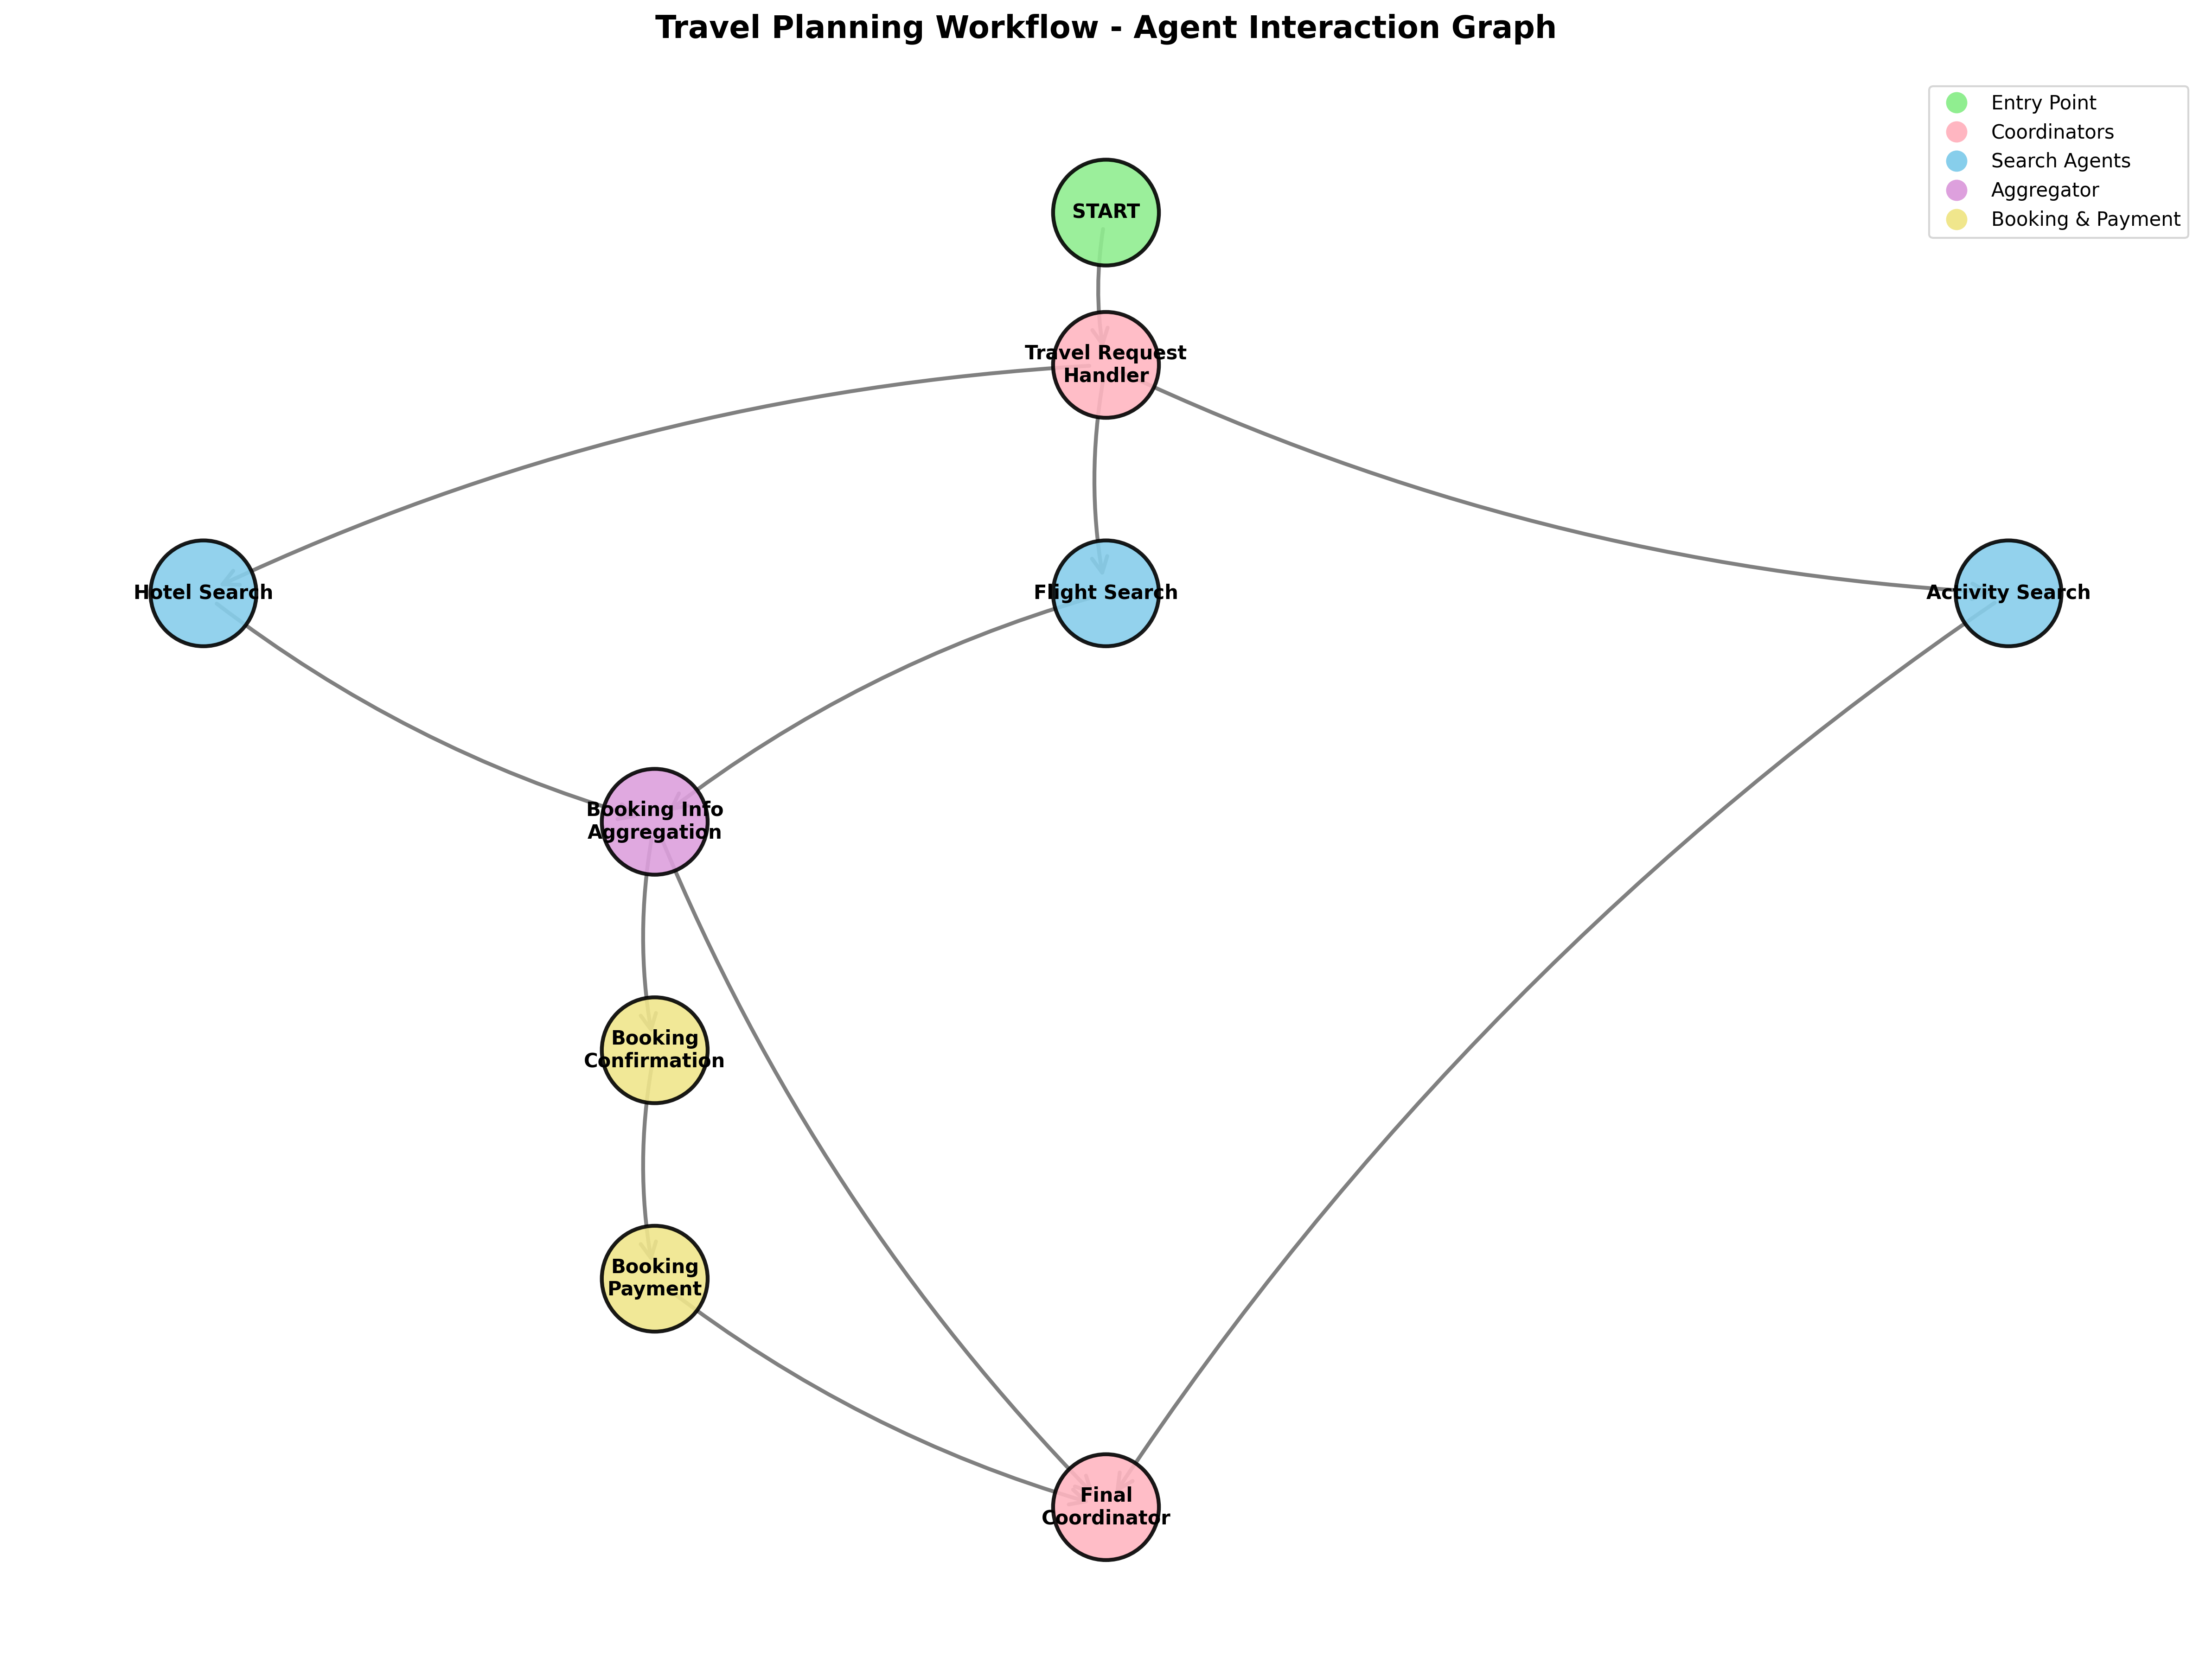

In [ ]:
# Run workflow directly by importing and calling the main function
import sys
from pathlib import Path

# Add the workflow directory to path to import the workflow module
workflow_dir = Path.cwd()
if str(workflow_dir) not in sys.path:
    sys.path.insert(0, str(workflow_dir))

# Import and run the workflow
from workflow_evaluation_multi_response import main_async
import asyncio

print("Running travel planning workflow...")
print("It might take a while for the workflow execution to complete...\n")
await main_async()
print("\n✓ Workflow execution completed")

Running travel planning workflow...
It might take a while for the workflow execution to finish...
Query: Plan a 3-day trip to Paris from December 15-18, 2025. Budget is $2000. Need hotel near Eiffel Tower, round-trip flights from New York JFK, and recommend 2-3 activities per day.


Workflow Output: ### Comprehensive Travel Plan for Paris Trip (December 15-18, 2025)

#### Overview:
- **Trip Duration:** 3 days 
- **Travel Dates:** December 15-18, 2025
- **Budget:** $2000
- **Departure:** New York JFK
- **Destination:** Paris (CDG)

---

### 1. Flights
- **Airline:** Air France
  - **Departure:** December 15, 2025, at 6:30 PM from JFK
  - **Arrival:** December 16, 2025, at 8:15 AM at CDG
  - **Duration:** 7 hours 45 minutes
  - **Flight Number:** AF007
  - **Cabin Class:** Economy
  - **Price:** **$520** (round-trip for one person, including 1 checked bag)

- **Return Flight:**
  - **Departure:** December 18, 2025, at 11:00 AM from CDG
  - **Arrival:** December 18, 2025, at 2:15 PM at JF

## Step 2: Load Agent Response IDs

Load workflow results with agent response and conversation IDs.

In [3]:
json_file_path = "workflow_agent_ids_multi_response.json"

with open(json_file_path, 'r', encoding='utf-8') as f:
    workflow_data = json.load(f)

print(f"Query: {workflow_data['query']}\n")
print(f"{'='*80}")
print(f"Available Agents and Their Responses:")
print(f"{'='*80}\n")

for agent_name, agent_data in workflow_data['agents'].items():
    response_count = agent_data['response_count']
    print(f"{agent_name}: {response_count} response(s)")
    if agent_data['response_ids']:
        print(f"  Latest Response ID: {agent_data['response_ids'][-1]}")
    print()

Query: Plan a 3-day trip to Paris from December 15-18, 2025. Budget is $2000. Need hotel near Eiffel Tower, round-trip flights from New York JFK, and recommend 2-3 activities per day.

Available Agents and Their Responses:

booking_payment_agent: 2 response(s)
  Latest Response ID: resp_09764d75a0119ec8006911c3a67cd48190bfb2a9f95e7e4cd9

travel_request_handler: 1 response(s)
  Latest Response ID: resp_5f8e58610ac41bac006911c330fea48190a5f8cc8f9048c462

flight_search_agent: 2 response(s)
  Latest Response ID: resp_708aaaee1f2b1c56006911c3488fa48190ba6d09f166e7f17a

hotel_search_agent: 2 response(s)
  Latest Response ID: resp_720f99a6b962782f006911c3447f6c81909d476fc2ced5e427

booking_info_aggregation_agent: 2 response(s)
  Latest Response ID: resp_0ea7dddf48ec9467006911c363147081908a6f46848531cab2

activity_search_agent: 2 response(s)
  Latest Response ID: resp_5b0492094d49a04a006911c348a06881909561d7e4baf2b318

booking_confirmation_agent: 4 response(s)
  Latest Response ID: resp_bbd807

## Step 4: Retrieve Final Response per Agent

Fetch the last response for each agent to inspect the output.

In [8]:
# Select 3 agents with responses for detailed inspection
agents_to_inspect = ["travel_request_handler", "hotel_search_agent", "flight_search_agent", "final_coordinator"]

print("Retrieving final responses:\n")
for agent_name in agents_to_inspect:
    if agent_name in workflow_data['agents']:
        agent_data = workflow_data['agents'][agent_name]
        if agent_data['response_ids']:
            response_id = agent_data['response_ids'][-1]  # Get last response
            print(f"{agent_name}:")
            print(f"  Response ID: {response_id}")
            
            try:
                response = openai_client.responses.retrieve(response_id=response_id)
                
                # Extract text content from the response structure
                if hasattr(response, 'output') and response.output:
                    # response.output is a list of ResponseOutputMessage objects
                    for message in response.output:
                        if hasattr(message, 'content') and message.content:
                            # message.content is a list of content items
                            for content_item in message.content:
                                if hasattr(content_item, 'text'):
                                    text = content_item.text
                                    # Truncate for display
                                    content = text[:1000] + "..." if len(text) > 1000 else text
                                    print(f"  Content: {content}")
                                    print("----" * 50)
                                    break
                            break
            except Exception as e:
                print(f"  Error retrieving: {e}")
            print()

Retrieving final responses:

travel_request_handler:
  Response ID: resp_5f8e58610ac41bac006911c330fea48190a5f8cc8f9048c462
  Content: **Travel Query Summary:**

- **Destination:** Paris, France
- **Dates:** December 15-18, 2025
- **Budget:** $2000
- **Preferences:**
  - Hotel near the Eiffel Tower
  - Round-trip flights from New York JFK
  - Recommended 2-3 activities per day

Please proceed with the planning!
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

hotel_search_agent:
  Response ID: resp_720f99a6b962782f006911c3447f6c81909d476fc2ced5e427
  Content: **Travel Query Summary:**

- **Destination:** Paris, France
- **Dates:** December 15-18, 2025
- **Budget:** $2000
- **Preferences:**
  - Hotel near the Eiffel Tower
  - Round-trip flights from New York JFK
  - Recommended 2-3 activities per day

Please proceed with the planning!
-

## Step 5: Create Evaluation with Multiple Evaluators

Set up evaluation with 5 evaluators: intent_resolution, relevance, groundedness, tool_call_accuracy, and task_adherence.

In [ ]:
model_deployment_name = os.environ.get("AZURE_AI_MODEL_DEPLOYMENT_NAME", "gpt-4o-mini")

data_source_config = {"type": "azure_ai_source", "scenario": "responses"}

testing_criteria = [
    {"type": "azure_ai_evaluator", "name": "intent_resolution", 
     "evaluator_name": "builtin.intent_resolution",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "relevance", 
     "evaluator_name": "builtin.relevance",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "groundedness", 
     "evaluator_name": "builtin.groundedness",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "tool_call_accuracy", 
     "evaluator_name": "builtin.tool_call_accuracy",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "task_adherence", 
     "evaluator_name": "builtin.task_adherence",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
]

eval_object = openai_client.evals.create(
    name="Travel Workflow Multi-Evaluator Assessment",
    data_source_config=data_source_config,
    testing_criteria=testing_criteria,
)

print(f"✓ Evaluation created")
print(f"  ID: {eval_object.id}")
print(f"  Name: {eval_object.name}")
print(f"  Evaluators: {len(testing_criteria)}")


Running evaluation for: hotel_search_agent
Response ID: resp_35b16a70a0ceffc700690b42e8d36c8190b77cfda547d721ba
  Evaluation run created (id: evalrun_57e2ba18c75b4f0a9857a60f74f1f018)
  Status: in_progress
  Waiting... Status: in_progress
  Waiting... Status: in_progress
  Waiting... Status: completed

  ✓ Evaluation completed successfully!
  Result Counts: ResultCounts(errored=0, failed=0, passed=1, total=1)
  Total output items: 1

Running evaluation for: flight_search_agent
Response ID: resp_6f2835cdda58c20b00690b42e8c6988190b15da0fc3a1d34b4
  Evaluation run created (id: evalrun_abdfd8a4afd44126ab3d2a17bcc33086)
  Status: in_progress
  Waiting... Status: in_progress
  Waiting... Status: completed

  ✓ Evaluation completed successfully!
  Result Counts: ResultCounts(errored=0, failed=0, passed=1, total=1)
  Total output items: 1

All evaluations completed!


## Step 6: Run Evaluation on Selected Responses

Evaluate 3 agent responses using all 5 evaluators.

In [ ]:
# Select 3 response IDs from different agents
selected_response_ids = []
selected_agent_names = ["hotel_search_agent", "flight_search_agent", "final_coordinator"]

for agent_name in selected_agent_names:
    if agent_name in workflow_data['agents']:
        agent_data = workflow_data['agents'][agent_name]
        if agent_data['response_ids']:
            selected_response_ids.append(agent_data['response_ids'][-1])

print(f"Selected {len(selected_response_ids)} response IDs for evaluation:")
for i, resp_id in enumerate(selected_response_ids, 1):
    print(f"  {i}. {resp_id}")

# Create data source with selected response IDs
data_source = {
    "type": "azure_ai_responses",
    "item_generation_params": {
        "type": "response_retrieval",
        "data_mapping": {"response_id": "{{item.resp_id}}"},
        "source": {
            "type": "file_content",
            "content": [{"item": {"resp_id": resp_id}} for resp_id in selected_response_ids]
        },
    },
}

# Create evaluation run
response_eval_run = openai_client.evals.runs.create(
    eval_id=eval_object.id, 
    name="Multi-Agent Response Evaluation", 
    data_source=data_source
)

print(f"\n✓ Evaluation run created (id: {response_eval_run.id})")

{
  "id": "resp_56ed85dfccf9366600690fa2c07dfc819098d8cdddba327b96",
  "created_at": 1762632384.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "you are a math calculator , you are supposed to answer math questions",
  "metadata": {},
  "model": "gpt-4o-mini-2024-07-18",
  "object": "response",
  "output": [
    {
      "id": "msg_56ed85dfccf9366600690fa2c2bf50819096df3040dbccf5ec",
      "content": [
        {
          "annotations": [],
          "text": "I will search again for the current price of gold. Please hold on for a moment.",
          "type": "output_text",
          "logprobs": []
        }
      ],
      "role": "assistant",
      "status": "completed",
      "type": "message",
      "partition_key": "56ed85dfccf9366600"
    },
    {
      "id": "msg_56ed85dfccf9366600690fa2c469d08190baa19bb1a5b0bb84",
      "content": [
        {
          "annotations": [],
          "text": "As of now, the price of gold is approximately $1,979.30 per ounce .",
   

In [ ]:
## Step 7: Wait for Completion

Monitor evaluation progress.

{
  "id": "resp_ed97feadb07d7eb100690e3eaf8624819090c136abe42a1b66",
  "created_at": 1762541232.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "You are a payment processing specialist. Handle payment transactions for travel bookings. Only use the tools provided and only use the information from the tools to answer the question. If the tools do not provide enough information, respond with 'no further information provided'.",
  "metadata": {},
  "model": "gpt-4o-mini-2024-07-18",
  "object": "response",
  "output": [
    {
      "id": "msg_ed97feadb07d7eb100690e3eb4130c819097b1d00c81c5bdc8",
      "content": [
        {
          "annotations": [],
          "text": "It seems there's an issue with processing payments due to missing payment method details. \n\n### Confirm Your Payment Method\nPlease provide the payment method details needed to complete the bookings for:\n\n1. **Flights**: $300 (for 2 people)\n2. **Hotel**: $450 (3 nights)\n3. **Activities**: \n   - Ei

In [ ]:
while response_eval_run.status not in ["completed", "failed"]:
    response_eval_run = openai_client.evals.runs.retrieve(
        run_id=response_eval_run.id, 
        eval_id=eval_object.id
    )
    print(f"Status: {response_eval_run.status}")
    time.sleep(5)

if response_eval_run.status == "completed":
    print("\n✓ Evaluation completed successfully!")
    print(f"Result Counts: {response_eval_run.result_counts}")
    print(f"Report URL: {response_eval_run.report_url}")
else:
    print("\n✗ Evaluation failed")

{
  "id": "resp_e1af3319e488e8bf00690e3e91b7ec8190b96c3728f9a8d149",
  "created_at": 1762541202.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "You are a booking confirmation specialist. Verify and confirm travel bookings. Only use the tools provided and only use the information from the tools to answer the question. If the tools do not provide enough information, respond with 'no further information provided'.",
  "metadata": {},
  "model": "gpt-4o-mini-2024-07-18",
  "object": "response",
  "output": [
    {
      "id": "msg_e1af3319e488e8bf00690e3e96a15081908619e6518b75e107",
      "content": [
        {
          "annotations": [],
          "text": "### Availability for Your Paris Trip (December 15-18, 2025)\n\n1. **Flights:**\n   - **Availability:** Available\n   - **Price:** $150 (per person, round-trip from JFK to CDG)\n   - **Slots Available:** 8\n\n2. **Hotel:**\n   - **Hotel Name:** Hotel de la Comète\n   - **Availability:** Limited (2 slots available)\n